# Spatial analysis via flatmaps

Note: this notebook requires FreeSurfer 7.3.2 and a different virtual environment (specifications in flatmap_env_requirements.txt)

## Setup

In [ ]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(project_root, 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

from utils.flatmaps import plot_Yeo_flatmap, stack_flatmaps
import numpy as np

from statsmodels.stats.multitest import multipletests

from utils import flatmaps 

# set paths to Yeo parcellation files
lh_path = "/Users/nicolerogalla/Downloads/lh.Schaefer2018_1000Parcels_7Networks_order.annot"
rh_path = "/Users/nicolerogalla/Downloads/rh.Schaefer2018_1000Parcels_7Networks_order.annot"

flatmaps.setup_parcels(lh_path, rh_path)

subjects = [1,2,3,5]

# set folder where results should be saved
res_dir = r"/Users/nicolerogalla/Documents/AFM/Flow-Matching-for-Probabilistic-Forecasting-of-fMRI-Time-Series/Results" 


## Yeo networks


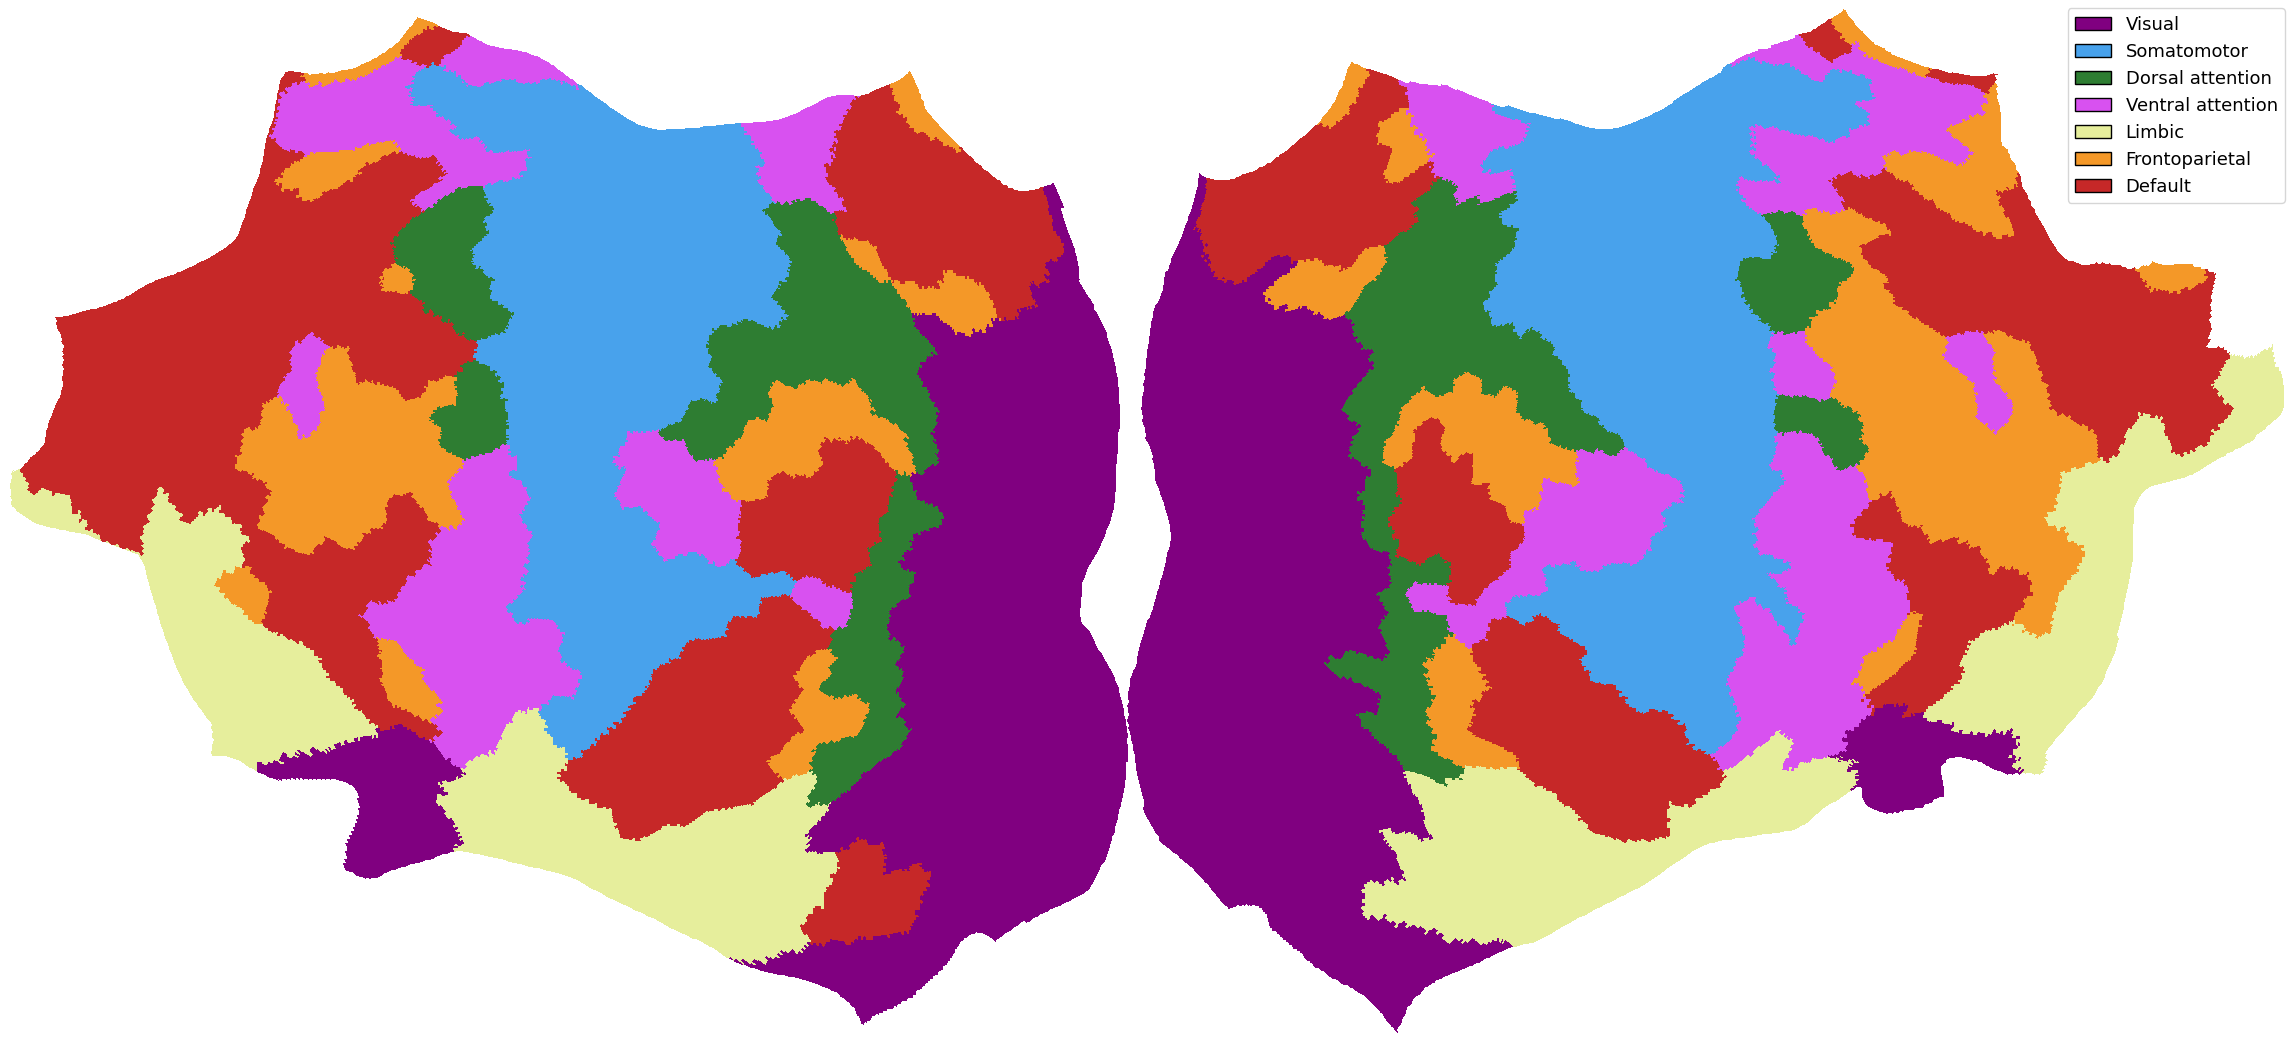

In [ ]:
plot_Yeo_flatmap()

## Flatmap Results


### Noise ceiling flatmaps


In [ ]:
noise_ceil_per_subj = np.load(f'{res_dir}/noise_ceil.npz')#get_Y(res_dir, subjects, framework, modeltype, "testset", hyper)

noise_ceil_per_subj = [noise_ceil_per_subj[key] for key in noise_ceil_per_subj]
mean_noise_ceil = np.mean(np.array(noise_ceil_per_subj), axis=0)\

noise_ceil_per_subj.insert(0, mean_noise_ceil)
stack_flatmaps(
    noise_ceil_per_subj,
    ["mean", "sub-01", "sub-02", "sub-03", "sub-05"],
    f"{res_dir}/noise_ceil_flatmaps.png",
    cmap='hot',
    vmin=None,
    vmax=None,
    label="$r$",
)


### Activation flatmaps


In [ ]:
y_true_per_subject = np.load(f'{res_dir}/y_true.npz')#get_Y(res_dir, subjects, framework, modeltype, "testset", hyper)

y_true_per_subject_list = [y_true_per_subject[key] for key in y_true_per_subject]
mean_y_true = np.mean(np.array(y_true_per_subject_list), axis=0)

y_true_per_subject_list.insert(0, mean_y_true)
stack_flatmaps(
    y_true_per_subject_list,
    ["mean", "sub-01", "sub-02", "sub-03", "sub-05"],
    f"{res_dir}/trueactivation.png",
    cmap='hot',
    vmin=None,
    vmax=None,
    label="$r*$",
)

### Framework Flatmaps

In [ ]:
frameworks = ["afm", "sfm", "regression"]
modeltypes = ["gru", "gru", "None"]
hypers = ["optimized", "optimized", "gru"]
for framework, modeltype, hyper in zip(frameworks, modeltypes, hypers):
    afm_preds = np.load(f'{res_dir}/{framework}_corrs.npz')

    afm_preds_per_subject_list = [afm_preds[key] for key in afm_preds]
    mean_pred = np.mean(np.array(afm_preds_per_subject_list), axis=0)\

    afm_preds_per_subject_list.insert(0, mean_pred)

    reject_maps = []
    subjects2 = ["mean",1,2,3,5]

    for subject in subjects2:
        p_map = np.load(fr"{res_dir}/{framework}tochance.npz")[f"{subject}_parcels_vs_chance"][1]
        reject, p_corr, _, _ = multipletests(p_map, alpha=0.05, method="fdr_bh")
        reject_maps.append(reject)
    
    # flatmaps in one column for all subjects 
    stack_flatmaps(
        afm_preds_per_subject_list,
        ["mean", "sub-01", "sub-02", "sub-03", "sub-05"],
        f"{res_dir}/{framework}_pred_flatmaps.png",
        reject_map_per_subject=reject_maps,
        cmap='hot',
        vmin=None,
        vmax=None,
        label="$r*$",
    )
    
    if framework == "afm": 


        mainres_corrs = [afm_preds_per_subject_list[0]]
        mainres_reject_map =[reject_maps[0]]
        # mean flatmap of AFM for main results
        stack_flatmaps(
            mainres_corrs,
            ["AFM"],
            f"{res_dir}/main_res_flatmaps.png",
            reject_map_per_subject=mainres_reject_map,
            cmap='hot',
            vertical = False,
            vmin=None,
            vmax=None,
            label="$r*$",
            cbar_rel_width=0.05
        )

### Comparison flatmaps


In [ ]:
mainres_corrs = []
mainres_reject_map = []

framework1 = "afm"
modeltype1 = "gru"
hyper1 = "optimized"

frameworks2 = ["regression", "sfm"]
modeltypes2 = ["None", "gru"]
hypers2 = ["default", "optimized"]
for (framework2, modeltype2, hyper2) in zip(frameworks2, modeltypes2, hypers2):
    reject_maps = []
    subjects2 = ["mean",1,2,3,5]
    diffs = []

    for subject in subjects2:
        
        obs_map, p_map = np.load(fr"{res_dir}/{framework2}to{framework1}.npz")[f"{subject}_{framework2}_{modeltype2}_{hyper2}__vs__{framework1}_{modeltype1}_{hyper1}_parcels"]
        reject, p_corr, _, _ = multipletests(p_map, alpha=0.05, method="fdr_bh")
        reject_maps.append(reject)
        diffs.append(-obs_map)
    
    mainres_corrs.append(diffs[0])
    mainres_reject_map.append(reject_maps[0])

    # per subject column flatmaps
    stack_flatmaps(
        diffs,
        ["mean", "sub-01", "sub-02", "sub-03", "sub-05"],
        f"{res_dir}/{framework1}_vs_{framework2}_flatmaps.png",
        reject_map_per_subject=reject_maps,
        cmap='hot',
        vmin=None,
        vmax=None,
        label="$\Delta r*$",
    )

# mean comparison flatmaps
stack_flatmaps(
    mainres_corrs,
     ["AFM vs GLM", "AFM vs SFM"],
    f"{res_dir}/main_comp_flatmaps.png",
    reject_map_per_subject=mainres_reject_map,
    cmap='hot',
    vertical = False,
    vmin=None,
    vmax=None,
    label="$\Delta r*$",
    cbar_rel_width=0.05
)


## CRPS flatmap


In [ ]:
crps_dir = "/Users/nicolerogalla/Documents/AFM/new_outputs/crps_outputs_afm"
crps_per_subject = []
for subject in subjects:
    crps_per_subject.append(np.load(f'{crps_dir}/{subject}.npy'))#get_Y(res_dir, subjects, framework, modeltype, "testset", hyper)

crps_per_subject.insert(0, np.mean(crps_per_subject, axis =0))

stack_flatmaps(
    crps_per_subject,
    ["mean", "sub-01", "sub-02", "sub-03", "sub-05"],
    f"{res_dir}/crps_afm.png",
    cmap='hot',
    vmin=None,
    vmax=None,
    label="CRPS",
)

In [ ]:
crps_dir_afm = "/Users/nicolerogalla/Documents/AFM/new_outputs/crps_outputs_afm"
crps_dir_sfm = "/Users/nicolerogalla/Documents/AFM/new_outputs/crps_outputs_sfm"
crps_per_subject = []
for subject in subjects:
    crps_afm = np.load(f'{crps_dir_afm}/{subject}.npy')
    crps_sfm = np.load(f'{crps_dir_sfm}/{subject}.npy')
    crps_per_subject.append(crps_afm -crps_sfm)#get_Y(res_dir, subjects, framework, modeltype, "testset", hyper)

crps_per_subject.insert(0, np.mean(crps_per_subject, axis =0))

stack_flatmaps(
    crps_per_subject,
    [f"mean ({np.sum(crps_per_subject[0]<=0)} / 1000)", f"sub-01 ({np.sum(crps_per_subject[1]<=0)} / 1000)", f"sub-02 ({np.sum(crps_per_subject[2]<=0)} / 1000)", f"sub-03 ({np.sum(crps_per_subject[3]<=0)} / 1000)", f"sub-05({np.sum(crps_per_subject[4]<=0)} / 1000)"],
    f"{res_dir}/crps_comp.png",
    cmap='hot',
    vmin=None,
    vmax=None,
    label="$\Delta$ CRPS",
)